# READING DATA INTO A DATAFRAME

In [380]:
import pandas as pd
df = pd.read_csv("Data.csv")
df

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      150 non-null    float64
 1   x2      150 non-null    float64
 2   x3      150 non-null    float64
 3   y       150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


# K - MEAN


DATA: 
     x1   x2   x3    y
0  5.1  3.5  1.4  0.2
1  4.9  3.0  1.4  0.2
2  4.7  3.2  1.3  0.2
3  4.6  3.1  1.5  0.2
4  5.0  3.6  1.4  0.2

DATA SIZE:  150



Enter the value of k:  3


FINAL CLUSTERS WITH k = 3, {1: [(5.1, 3.5, 1.4, 0.2), (4.9, 3.0, 1.4, 0.2), (4.7, 3.2, 1.3, 0.2), (4.6, 3.1, 1.5, 0.2), (5.0, 3.6, 1.4, 0.2), (5.4, 3.9, 1.7, 0.4), (4.6, 3.4, 1.4, 0.3), (5.0, 3.4, 1.5, 0.2), (4.4, 2.9, 1.4, 0.2), (4.9, 3.1, 1.5, 0.1), (5.4, 3.7, 1.5, 0.2), (4.8, 3.4, 1.6, 0.2), (4.8, 3.0, 1.4, 0.1), (4.3, 3.0, 1.1, 0.1), (5.8, 4.0, 1.2, 0.2), (5.7, 4.4, 1.5, 0.4), (5.4, 3.9, 1.3, 0.4), (5.1, 3.5, 1.4, 0.3), (5.7, 3.8, 1.7, 0.3), (5.1, 3.8, 1.5, 0.3), (5.4, 3.4, 1.7, 0.2), (5.1, 3.7, 1.5, 0.4), (4.6, 3.6, 1.0, 0.2), (5.1, 3.3, 1.7, 0.5), (4.8, 3.4, 1.9, 0.2), (5.0, 3.0, 1.6, 0.2), (5.0, 3.4, 1.6, 0.4), (5.2, 3.5, 1.5, 0.2), (5.2, 3.4, 1.4, 0.2), (4.7, 3.2, 1.6, 0.2), (4.8, 3.1, 1.6, 0.2), (5.4, 3.4, 1.5, 0.4), (5.2, 4.1, 1.5, 0.1), (5.5, 4.2, 1.4, 0.2), (4.9, 3.1, 1.5, 0.2), (5.0, 3.2, 1.2, 0.2), (5.5, 3.5, 1.3, 0.2), (4.9, 3.6, 1.4, 0.1), (4.4, 3.0, 1.3, 0.2), (5.1, 3.4, 1.5, 0.2), (5.0, 3.5, 1.3, 0.3), (4.5, 2.3, 1.3, 0.3), (4.4, 3.2, 1.3, 0.2), (5.0, 3.5, 1.6, 0.6), 

C:\Users\muzam\AppData\Local\Temp\ipykernel_8816\1995752308.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", k).colors


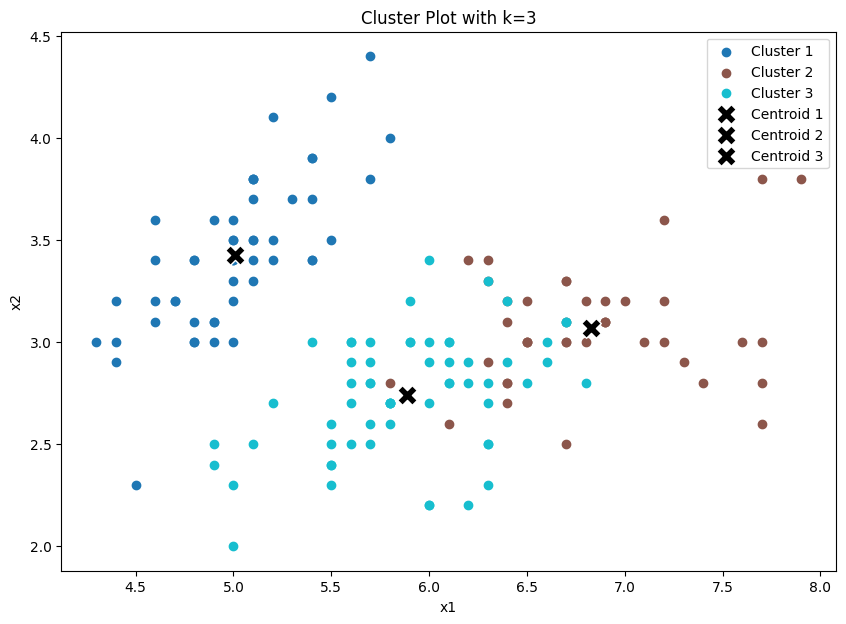

In [170]:
# K - MEAN


#libraries
import numpy as np
import matplotlib.pyplot as plt
import random

print("\nDATA: \n", df.head())
dataSize = df.shape[0]
print("\nDATA SIZE: ", dataSize)

'''#min max normalisation
df['x1'] = (df['x1'] - df['x1'].min()) / (df['x1'].max() - df['x1'].min())
df['x2'] = (df['x2'] - df['x2'].min()) / (df['x2'].max() - df['x2'].min())
df['x3'] = (df['x3'] - df['x3'].min()) / (df['x3'].max() - df['x3'].min())
df['y'] = (df['y'] - df['y'].min()) / (df['y'].max() - df['y'].min())      
'''

k = int(input("\nEnter the value of k: "))

#changing clusters
centroids = {}
clusters = {}

#initialise new centroids k times
for cIter in range(1, k + 1):
    
    startIndex = random.randint(0,len(df)-1)
    x1 = df['x1'][startIndex]
    x2 = df['x2'][startIndex]
    x3 = df['x3'][startIndex]
    y = df['y'][startIndex]

    
    centroid = (x1, x2, x3, y)
    centroids[cIter] = centroid


#update centroids based on no. of iterations
for costIter in range(10):

    #make empty clusters to add points
    for cIter in range(1, k + 1):
        clusters[cIter] = []

    #for each point it is closer to which cluster
    for dataIndexIter in range(dataSize):
        
        x1 = df['x1'][dataIndexIter]
        x2 = df['x2'][dataIndexIter]
        x3 = df['x3'][dataIndexIter]
        y = df['y'][dataIndexIter]
        thisDataPoint = (x1,x2,x3,y)
        distances = []

        #get point's distance from all clusters
        for cIter in range(1, k+1):
            thisDataPointDistance = (((centroids[cIter][0] - thisDataPoint[0]) ** 2 + (centroids[cIter][1] - thisDataPoint[1]) ** 2  + (centroids[cIter][2] - thisDataPoint[2]) ** 2 + (centroids[cIter][3] - thisDataPoint[3]) ** 2)) ** 0.5
            distances.append((thisDataPointDistance, cIter))

        
        
        minimumDistance = min(distances)
        clusters[minimumDistance[1]].append((df.iloc[dataIndexIter, 0], df.iloc[dataIndexIter, 1], df.iloc[dataIndexIter, 2], df.iloc[dataIndexIter, 3]))
        

    finalSSE = 0
    for cIter in range(k):
        thisCluster = clusters[cIter + 1]
        thisSSE = 0
        for dataSizeIter in range(len(thisCluster)):
            thisSSE += (((thisCluster[dataSizeIter][0] - centroids[cIter + 1][0]) ** 2) + ((thisCluster[dataSizeIter][1] - centroids[cIter + 1][1]) ** 2)+ ((thisCluster[dataSizeIter][2] - centroids[cIter + 1][2]) ** 2) + ((thisCluster[dataSizeIter][3] - centroids[cIter + 1][3]) ** 2))
        
        finalSSE += thisSSE

     
    newCentroids = {}

    #k centroids to update
    for cIter in range(k):
        #initialise new centroid
        newCentroids[cIter + 1] = (0, 0, 0, 0)

        #if cluster has atleast one element then update its centroid
        if len(clusters[cIter + 1]) > 0:
            x1 = 0
            x2 = 0
            x3 = 0
            y = 0
            
            for dataPointSizeIter in range(len(clusters[cIter + 1])):
                x1 += clusters[cIter + 1][dataPointSizeIter][0]
                x2 += clusters[cIter + 1][dataPointSizeIter][1]
                x3 += clusters[cIter + 1][dataPointSizeIter][2]
                y += clusters[cIter + 1][dataPointSizeIter][3]
            
            newCentroid = (x1 / len(clusters[cIter + 1]), x2 / len(clusters[cIter + 1]), x3 / len(clusters[cIter + 1]), y / len(clusters[cIter + 1]))
            newCentroids[cIter + 1] = newCentroid

    centroids = newCentroids
    
print(f"FINAL CLUSTERS WITH k = {k}, {clusters}\n")
print(f"SSE with k = {k}: {finalSSE}\n")


colors = plt.cm.get_cmap("tab10", k).colors 

plt.figure(figsize=(10, 7))

for cIter in range(1, k + 1):
    cluster_points = np.array(clusters[cIter])
    if(len(cluster_points) != 0):
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=[colors[cIter - 1]], label=f'Cluster {cIter}')

# Plot the centroids
for cIter, centroid in centroids.items():
    plt.scatter(centroid[0], centroid[1], marker='X', s=200, color='black', edgecolor='w', label=f'Centroid {cIter}')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Cluster Plot with k={k}')
plt.legend()
plt.show()



# ADVANTAGES

Efficiency: It is computationally faster, especially for large datasets, as it uses mean-based centroids.

Simple to Implement: The algorithm is easy to understand and implement.

Scalability: Suitable for large datasets due to its O(nkt) complexity (where n = number of points, k = number of clusters, t = number of iterations).

# DISADVANTAGES

Sensitive to Initialization: The final result depends on the initial selection of centroids. Poor initialization can lead to suboptimal clustering.

Assumes spherical clusters: It assumes clusters to be spherical and equal in size, making it unsuitable for non-spherical or irregularly shaped clusters.

Outlier Sensitivity: It is sensitive to outliers as they can distort the mean.

# K - MEDOID


DATA: 
     x1   x2   x3    y
0  5.1  3.5  1.4  0.2
1  4.9  3.0  1.4  0.2
2  4.7  3.2  1.3  0.2
3  4.6  3.1  1.5  0.2
4  5.0  3.6  1.4  0.2

DATA SIZE:  150



Enter the value of k:  3


FINAL CLUSTERS WITH k = 3, {1: [(6.8, 2.8, 4.8, 1.4), (6.7, 3.0, 5.0, 1.7), (7.1, 3.0, 5.9, 2.1), (6.5, 3.0, 5.8, 2.2), (7.6, 3.0, 6.6, 2.1), (7.2, 3.6, 6.1, 2.5), (6.8, 3.0, 5.5, 2.1), (5.8, 2.8, 5.1, 2.4), (6.4, 3.2, 5.3, 2.3), (7.7, 3.8, 6.7, 2.2), (7.7, 2.6, 6.9, 2.3), (6.9, 3.2, 5.7, 2.3), (5.6, 2.8, 4.9, 2.0), (7.7, 2.8, 6.7, 2.0), (6.7, 3.3, 5.7, 2.1), (7.7, 3.0, 6.1, 2.3), (6.9, 3.1, 5.4, 2.1), (6.7, 3.1, 5.6, 2.4), (6.9, 3.1, 5.1, 2.3), (6.8, 3.2, 5.9, 2.3), (6.7, 3.3, 5.7, 2.5), (6.7, 3.0, 5.2, 2.3), (6.5, 3.0, 5.2, 2.0)], 2: [(7.0, 3.2, 4.7, 1.4), (6.4, 3.2, 4.5, 1.5), (6.9, 3.1, 4.9, 1.5), (6.5, 2.8, 4.6, 1.5), (6.3, 3.3, 4.7, 1.6), (6.7, 3.1, 4.4, 1.4), (5.9, 3.2, 4.8, 1.8), (6.3, 2.5, 4.9, 1.5), (6.6, 3.0, 4.4, 1.4), (6.0, 2.7, 5.1, 1.6), (6.0, 3.4, 4.5, 1.6), (6.7, 3.1, 4.7, 1.5), (6.3, 3.3, 6.0, 2.5), (5.8, 2.7, 5.1, 1.9), (6.3, 2.9, 5.6, 1.8), (7.3, 2.9, 6.3, 1.8), (6.7, 2.5, 5.8, 1.8), (6.5, 3.2, 5.1, 2.0), (6.4, 2.7, 5.3, 1.9), (6.5, 3.0, 5.5, 1.8), (6.3, 2.7, 4.9, 1

C:\Users\muzam\AppData\Local\Temp\ipykernel_8816\683418578.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", k).colors


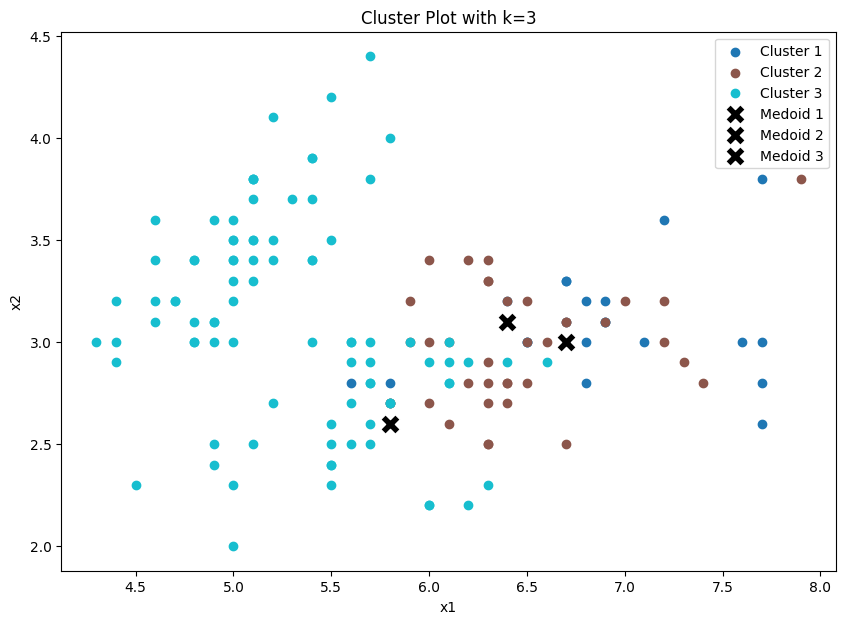

In [202]:
# K - MEDOID

#libraries
import numpy as np
import matplotlib.pyplot as plt
import random

print("\nDATA: \n", df.head())
dataSize = df.shape[0]
print("\nDATA SIZE: ", dataSize)

'''#min max normalisation
df['x1'] = (df['x1'] - df['x1'].min()) / (df['x1'].max() - df['x1'].min())
df['x2'] = (df['x2'] - df['x2'].min()) / (df['x2'].max() - df['x2'].min())
df['x3'] = (df['x3'] - df['x3'].min()) / (df['x3'].max() - df['x3'].min())
df['y'] = (df['y'] - df['y'].min()) / (df['y'].max() - df['y'].min())      
'''

k = int(input("\nEnter the value of k: "))


bestMD = np.inf
bestClusters = {}
bestMedoids = {}

#changing clusters
medoids = {}
clusters = {}


for iterations in range(100):
    for cIter in range(1, k + 1):
        startIndex = random.randint(0,len(df)-1)
        x1 = df['x1'][startIndex]
        x2 = df['x2'][startIndex]
        x3 = df['x3'][startIndex]
        y = df['y'][startIndex]
    
        medoid = (x1, x2, x3, y)
        medoids[cIter] = medoid
    
    #make empty clusters to add points
    for cIter in range(1, k + 1):
        clusters[cIter] = []

    #for each point it is closer to which cluster
    for dataIndexIter in range(dataSize):
        
        x1 = df['x1'][dataIndexIter]
        x2 = df['x2'][dataIndexIter]
        x3 = df['x3'][dataIndexIter]
        y = df['y'][dataIndexIter]
        thisDataPoint = (x1,x2,x3,y)
        distances = []

        #get point's distance from all clusters
        for cIter in range(1, k+1):
            thisDataPointDistance = (np.abs(medoids[cIter][0] - thisDataPoint[0]) + np.abs(medoids[cIter][1] - thisDataPoint[1])  + np.abs(medoids[cIter][2] - thisDataPoint[2]) + np.abs(medoids[cIter][3] - thisDataPoint[3]))
            distances.append((thisDataPointDistance, cIter))

        
        
        minimumDistance = min(distances)
        clusters[minimumDistance[1]].append((df.iloc[dataIndexIter, 0], df.iloc[dataIndexIter, 1], df.iloc[dataIndexIter, 2], df.iloc[dataIndexIter, 3]))
        

    finalMD = 0
    for cIter in range(k):
        thisCluster = clusters[cIter + 1]
        thisMD = 0
        for dataSizeIter in range(len(thisCluster)):
            thisMD += ((np.abs(thisCluster[dataSizeIter][0] - medoids[cIter + 1][0])) + np.abs((thisCluster[dataSizeIter][1] - medoids[cIter + 1][1]))+ np.abs((thisCluster[dataSizeIter][2] - medoids[cIter + 1][2])) + np.abs((thisCluster[dataSizeIter][3] - medoids[cIter + 1][3])))
        
        finalMD += thisMD

    if(finalMD < bestMD):
        bestClusters = clusters
        bestMD = finalMD
        bestMedoids = medoids

    
print(f"FINAL CLUSTERS WITH k = {k}, {clusters}\n")
print(f"Manhattan Cost with k = {k}: {bestMD}\n")


colors = plt.cm.get_cmap("tab10", k).colors 

plt.figure(figsize=(10, 7))

for cIter in range(1, k + 1):
    cluster_points = np.array(clusters[cIter])
    if(len(cluster_points) != 0):
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=[colors[cIter - 1]], label=f'Cluster {cIter}')

# Plot the centroids
for cIter, medoid in medoids.items():
    plt.scatter(medoid[0], medoid[1], marker='X', s=200, color='black', edgecolor='w', label=f'Medoid {cIter}')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Cluster Plot with k={k}')
plt.legend()
plt.show()



# Advantages:

Robust to Outliers: Unlike K-Means, K-Medoid uses actual data points as centroids (medoids), making it less sensitive to outliers.

Suitable for Arbitrary Shape Clusters: It can handle clusters of arbitrary shapes better than K-Means.

Works well for categorical data: Can be used for data types other than continuous (e.g., categorical or mixed data).

# Disadvantages:

Computational Complexity: K-Medoid is computationally more expensive than K-Means (O(n²*k)), especially for large datasets.

Initialization Sensitivity: Like K-Means, K-Medoid can be sensitive to the initial choice of medoids.

Slower for Large Data: As the dataset grows, the algorithm becomes slower, especially if using exhaustive methods for finding medoids.


# K - MEDIAN


DATA: 
     x1   x2   x3    y
0  5.1  3.5  1.4  0.2
1  4.9  3.0  1.4  0.2
2  4.7  3.2  1.3  0.2
3  4.6  3.1  1.5  0.2
4  5.0  3.6  1.4  0.2

DATA SIZE:  150



Enter the value of k:  3


FINAL CLUSTERS WITH k = 3, {1: [(7.0, 3.2, 4.7, 1.4), (6.4, 3.2, 4.5, 1.5), (6.9, 3.1, 4.9, 1.5), (6.5, 2.8, 4.6, 1.5), (6.3, 3.3, 4.7, 1.6), (5.9, 3.2, 4.8, 1.8), (6.3, 2.5, 4.9, 1.5), (6.8, 2.8, 4.8, 1.4), (6.7, 3.0, 5.0, 1.7), (6.0, 2.7, 5.1, 1.6), (6.7, 3.1, 4.7, 1.5), (6.3, 3.3, 6.0, 2.5), (5.8, 2.7, 5.1, 1.9), (7.1, 3.0, 5.9, 2.1), (6.3, 2.9, 5.6, 1.8), (6.5, 3.0, 5.8, 2.2), (7.6, 3.0, 6.6, 2.1), (7.3, 2.9, 6.3, 1.8), (6.7, 2.5, 5.8, 1.8), (7.2, 3.6, 6.1, 2.5), (6.5, 3.2, 5.1, 2.0), (6.4, 2.7, 5.3, 1.9), (6.8, 3.0, 5.5, 2.1), (5.8, 2.8, 5.1, 2.4), (6.4, 3.2, 5.3, 2.3), (6.5, 3.0, 5.5, 1.8), (7.7, 3.8, 6.7, 2.2), (7.7, 2.6, 6.9, 2.3), (6.9, 3.2, 5.7, 2.3), (7.7, 2.8, 6.7, 2.0), (6.3, 2.7, 4.9, 1.8), (6.7, 3.3, 5.7, 2.1), (7.2, 3.2, 6.0, 1.8), (6.2, 2.8, 4.8, 1.8), (6.1, 3.0, 4.9, 1.8), (6.4, 2.8, 5.6, 2.1), (7.2, 3.0, 5.8, 1.6), (7.4, 2.8, 6.1, 1.9), (7.9, 3.8, 6.4, 2.0), (6.4, 2.8, 5.6, 2.2), (6.3, 2.8, 5.1, 1.5), (6.1, 2.6, 5.6, 1.4), (7.7, 3.0, 6.1, 2.3), (6.3, 3.4, 5.6, 2.4), 

C:\Users\muzam\AppData\Local\Temp\ipykernel_8816\3551863650.py:99: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap("tab10", k).colors


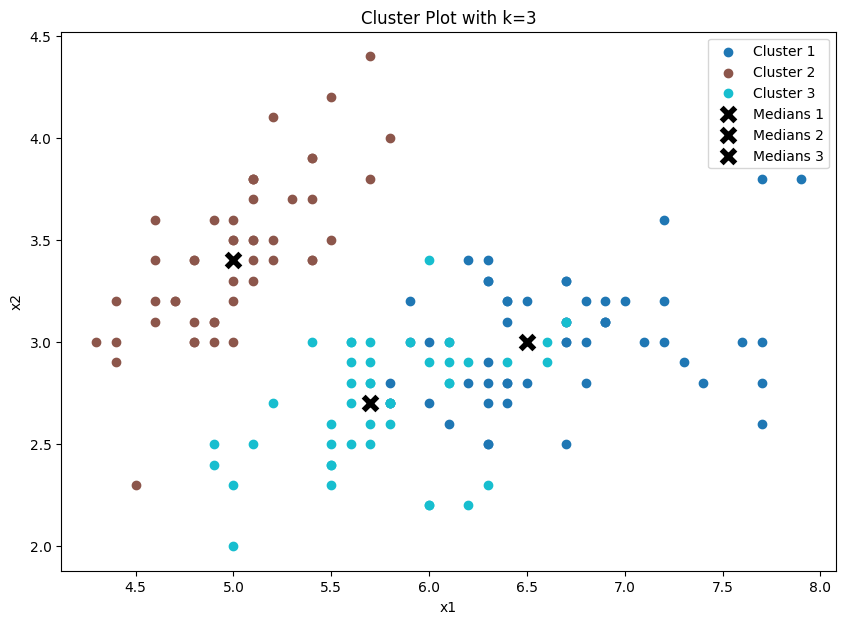

In [201]:
# K - MEDIAN 

#libraries
import numpy as np
import matplotlib.pyplot as plt
import random

print("\nDATA: \n", df.head())
dataSize = df.shape[0]
print("\nDATA SIZE: ", dataSize)

'''#min max normalisation
df['x1'] = (df['x1'] - df['x1'].min()) / (df['x1'].max() - df['x1'].min())
df['x2'] = (df['x2'] - df['x2'].min()) / (df['x2'].max() - df['x2'].min())
df['x3'] = (df['x3'] - df['x3'].min()) / (df['x3'].max() - df['x3'].min())
df['y'] = (df['y'] - df['y'].min()) / (df['y'].max() - df['y'].min())      
'''

k = int(input("\nEnter the value of k: "))

#changing clusters
medians = {}
clusters = {}

#initialise new centroids k times
for cIter in range(1, k + 1):
    
    startIndex = random.randint(0,len(df)-1)
    x1 = df['x1'][startIndex]
    x2 = df['x2'][startIndex]
    x3 = df['x3'][startIndex]
    y = df['y'][startIndex]

    
    median = (x1, x2, x3, y)
    medians[cIter] = median


for costIter in range(10):

    #make empty clusters to add points
    for cIter in range(1, k + 1):
        clusters[cIter] = []

    #for each point it is closer to which cluster
    for dataIndexIter in range(dataSize):
        
        x1 = df['x1'][dataIndexIter]
        x2 = df['x2'][dataIndexIter]
        x3 = df['x3'][dataIndexIter]
        y = df['y'][dataIndexIter]
        thisDataPoint = (x1,x2,x3,y)
        distances = []

        #get point's distance from all clusters
        for cIter in range(1, k+1):
            thisDataPointDistance = (np.abs(medians[cIter][0] - thisDataPoint[0]) + np.abs(medians[cIter][1] - thisDataPoint[1])  + np.abs(medians[cIter][2] - thisDataPoint[2]) + np.abs(medians[cIter][3] - thisDataPoint[3]))
            distances.append((thisDataPointDistance, cIter))

        
        
        minimumDistance = min(distances)
        clusters[minimumDistance[1]].append((df.iloc[dataIndexIter, 0], df.iloc[dataIndexIter, 1], df.iloc[dataIndexIter, 2], df.iloc[dataIndexIter, 3]))
        

    finalMD = 0
    for cIter in range(k):
        thisCluster = clusters[cIter + 1]
        thisMD = 0
        for dataSizeIter in range(len(thisCluster)):
            thisMD += ((np.abs(thisCluster[dataSizeIter][0] - medians[cIter + 1][0])) + np.abs((thisCluster[dataSizeIter][1] - medians[cIter + 1][1]))+ np.abs((thisCluster[dataSizeIter][2] - medians[cIter + 1][2])) + np.abs((thisCluster[dataSizeIter][3] - medians[cIter + 1][3])))
        
        finalMD += thisMD

     
    newMedians = {}

    #k centroids to update
    for cIter in range(k):
        #initialise new centroid
        newMedian = (0,0,0,0)

        #if cluster has atleast one element then update its centroid
        if len(clusters[cIter + 1]) > 0:    
            x1 = np.median([i[0] for i in clusters[cIter + 1]])
            x2 = np.median([i[1] for i in clusters[cIter + 1]])
            x3 = np.median([i[2] for i in clusters[cIter + 1]])
            y = np.median([i[3] for i in clusters[cIter + 1]])
            
            newMedian = (x1, x2, x3, y)
            newMedians[cIter + 1] = newMedian

    medians = newMedians
    
print(f"FINAL CLUSTERS WITH k = {k}, {clusters}\n")
print(f"MANHATTAN COST with k = {k}: {finalMD}\n")


colors = plt.cm.get_cmap("tab10", k).colors 

plt.figure(figsize=(10, 7))

for cIter in range(1, k + 1):
    cluster_points = np.array(clusters[cIter])
    if(len(cluster_points) != 0):
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=[colors[cIter - 1]], label=f'Cluster {cIter}')

# Plot the centroids
for cIter, median in medians.items():
    plt.scatter(median[0], median[1], marker='X', s=200, color='black', edgecolor='w', label=f'Medians {cIter}')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title(f'Cluster Plot with k={k}')
plt.legend()
plt.show()







# Advantages:

Robust to Outliers: Like K-Medoid, K-Median uses the median instead of the mean, making it more resistant to the influence of outliers.

Works for Mixed Data: It can handle both categorical and continuous data better than K-Means.

Better for Non-Normal Distributions: Because it uses the median, it is better suited for data that isn't normally distributed.

# Disadvantages:

Computationally Expensive: K-Median can be more computationally expensive than K-Means (though generally faster than K-Medoid).

Convergence Issues: It may not always converge as reliably as K-Means.

Less Intuitive: The concept of "centroid" is less intuitive with medians, which can make it harder to interpret the results.

# AGGLOMERATIVE CLUSTERING (SINGLE LINKAGE / COMPLETE LINKAGE / AVERAGE LINKAGE)

In [410]:
# AGGLOMERATIVE CLUSTERING (SINGLE LINKAGE)

import pandas as pd


#DATA IS IN THE DATAFRAME
df = pd.read_csv("Data.csv")


visited = []
#RETURNS THE POINT HAVING THE MINIMUM DISTANCE IN THE CLUSTERS
def singleLinkage(StrToIntMapping, mapping, cols):
    #cols 1
    #mapping = combined point

    if(cols != mapping):
        distances = []
        for part in StrToIntMapping[mapping]:
            
            if(type(cols) != str):
                distances.append(original.loc[cols][part])

            #if(type(cols) == str):
                #singleLinkage(StrToIntMapping, mapping, )
            
        result = min(distances)
        return result
    return 0       
            
def completeLinkage(StrToIntMapping, mapping, cols):
    distances = []
    for part in StrToIntMapping[mapping]:
        distances.append(original.loc[cols][part])
    return max(distances) if distances else 0


def averageLinkage(StrToIntMapping, mapping, cols):
    distances = []
    for part in StrToIntMapping[mapping]:
        distances.append(original.loc[cols][part])
    return sum(distances) / len(distances) if distances else 0
    
    
    
#TAKES TWO POINTS AND SHOULD RETURN THE EUCLEDEAN DISTANCE BETWEEN THE TWO POINTS
def EucledeanDistance(p1, p2):
    distance = 0
    for i in range(len(p1)):
        distance += (p1[i] - p2[i]) ** 2

    result = distance ** 0.5
    return result


#RETURNS MINIMUM OUT OF WHOLE OF THE DATAFRAME ALONG WITH THE ROW AND COLUMN WHERE IT IS LOCATED
def findMinimum(df2):
    minimum = [np.inf,0,0]
    for row in df2.columns:
        for col in df2.columns:
            text = str(f"{col},{row}")
            if((df2[col][row] < minimum[0]).any() and col != row and text not in visited):
                minimum = [df2.iloc[col, row], col, row]    
    return minimum



#GENERATES MATRIX OF N SQUARE
data = {}
for row in range(len(df)):
    data[row] = {}
    for col in range(len(df)):
        data[row][col] = 0

#CALLING IT THE ORIGINAL MATRIX
original = pd.DataFrame(data)


#FILLING THE N SQUARE WITH DISTANCES BETWEEN POINTS
for row in range(len(original)):
    for col in range(len(original)):
        original.iloc[col, row] = EucledeanDistance(tuple(df.iloc[col]), tuple(df.iloc[row]))


#COPY OF THE ORIGINAL DATAFRAME, ORIGINAL WILL REMAIN AS IT IS, DF2 WILL BE ALTERED
df2 = original.copy()

#FOR NEW KEYS TELLING THAT COLUMNS THEY HAVE WHICH WOULD BE USED TO MAP THE DISTANCES IN THE ORIGINAL DF
StrToIntMapping = {}

#SEE LATER BECAUSE WHILE DF2 != 1 THAT IS ONE WHOLE CLUSTER WHEN EVERYTHING COMBINES



while(len(df2) != 1):
    #print(1)
    #MINIMUM DISTANCE AND THE ROW[1] AND COLUMN[2]
    minimum = findMinimum(df2)
    #print(minimum)
    
    
    #JOIN THE TWO CLUSTERS
    text = str(f"{minimum[1]},{minimum[2]}")
    visited.append(text)
    #ADD POINTS FOR REFERENCE
    StrToIntMapping[text] = [minimum[1], minimum[2]]
    
    #DROP THE INDIVIDUAL POINTS THAT ARE COMBINED
    df2.drop(columns = [minimum[1], minimum[2]], inplace = True) #COLS
    df2.drop(index = [minimum[1], minimum[2]], inplace=True) #ROWS
    
    #ADD NEW COMBINED COLUMN
    df2[text] = 0
    #ADD NEW COMBINED ROW
    df2.loc[text] = [0 for i in range(len(df2.columns))]
    
    #RESET INDEX FOR NEW REFERENCING
    df2.reset_index()
    
    #FOR PUTTING NEW VALUES AT THE PLACE OF INDICES
    
    for cols in df2.columns:
        df2.loc[cols, text] = singleLinkage(StrToIntMapping, text, cols)
        df2.loc[text, cols] = singleLinkage(StrToIntMapping, text, cols)
    
    print(df2)


    










                0         1         2         3         4         5         6  \
0        0.000000  0.538516  0.509902  0.648074  0.141421  0.616441  0.519615   
1        0.538516  0.000000  0.300000  0.331662  0.608276  1.090871  0.509902   
2        0.509902  0.300000  0.000000  0.244949  0.509902  1.086278  0.264575   
3        0.648074  0.331662  0.244949  0.000000  0.648074  1.166190  0.331662   
4        0.141421  0.608276  0.509902  0.648074  0.000000  0.616441  0.458258   
...           ...       ...       ...       ...       ...       ...       ...   
146      4.276681  4.249706  4.430576  4.288356  4.330127  3.988734  4.384062   
147      4.459821  4.498889  4.661545  4.533211  4.504442  4.102438  4.593474   
148      4.650806  4.718050  4.848711  4.719110  4.678675  4.264974  4.749737   
149      4.140048  4.153312  4.298837  4.149699  4.173727  3.818377  4.217819   
142,101  4.208325  4.180909  4.334743  4.177320  4.246175  3.925557  4.263801   

                7         8

ValueError: min() arg is an empty sequence

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Generate linkage matrix using single linkage (for dendrogram)
Z = linkage(original, method='single')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z, labels=[str(i) for i in range(len(df))])
plt.title("Dendrogram (Single Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Plot Venn Diagram (for simplicity, we assume two or three clusters)
# Assuming sets are clusters found at the first step (for illustration)
if len(df) >= 3:
    plt.figure(figsize=(7, 7))
    venn3(subsets=(1, 1, 1, 1, 1, 1, 1), set_labels=('Cluster 1', 'Cluster 2', 'Cluster 3'))
    plt.title("Venn Diagram of Clusters")
    plt.show()
elif len(df) == 2:
    plt.figure(figsize=(7, 7))
    venn2(subsets=(1, 1, 1), set_labels=('Cluster 1', 'Cluster 2'))
    plt.title("Venn Diagram of Clusters")
    plt.show()
else:
    print("Venn diagrams are most meaningful for 2 or 3 clusters.")